Pasajeros con edad registrada: 714 de 891

Estadísticas de Edad:
  Media    : 29.7 años
  Mediana  : 28.0 años
  Std      : 14.5 años
  Sesgo    : 0.389
  Curtosis : 0.178


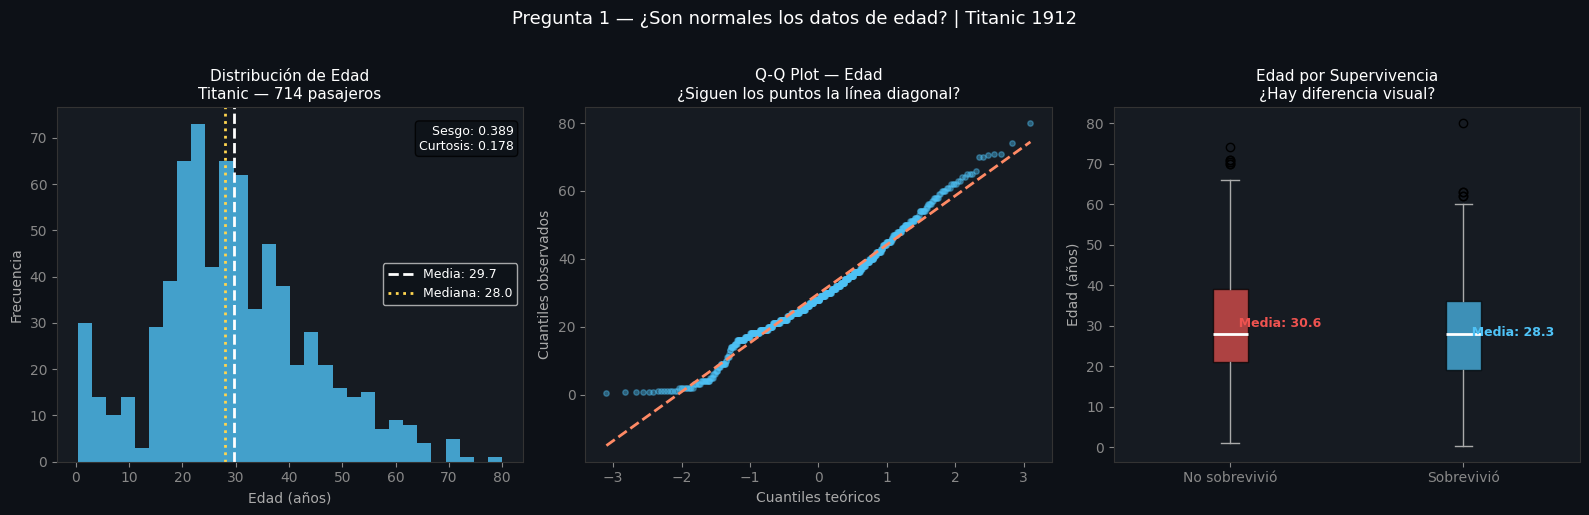


SHAPIRO-WILK — Test de Normalidad
Estadístico : 0.9796
p-value     : 0.000002
Conclusión  : ❌ No normal

INTERPRETACIÓN
Los datos de edad NO son normales.
→ Para comparar grupos usaremos tests
  no paramétricos O t-test con precaución
  (funciona bien con muestras grandes >30)


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

# ============================================================
# CARGA de DATOS
# ============================================================
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df  = pd.read_csv(url)

# Limpieza básica — solo edad sin nulos
df_edad = df['Age'].dropna()

print(f"Pasajeros con edad registrada: {len(df_edad)} de {len(df)}")
print(f"\nEstadísticas de Edad:")
print(f"  Media    : {df_edad.mean():.1f} años")
print(f"  Mediana  : {df_edad.median():.1f} años")
print(f"  Std      : {df_edad.std():.1f} años")
print(f"  Sesgo    : {df_edad.skew():.3f}")
print(f"  Curtosis : {df_edad.kurtosis():.3f}")

# ============================================================
# TEST DE NORMALIDAD
# ============================================================
stat, p_shapiro = stats.shapiro(df_edad[:500])
resultado = "✅ Normal" if p_shapiro > 0.05 else "❌ No normal"

# ============================================================
# VISUALIZACIÓN
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#0d1117')

# --- Gráfica 1: Histograma ---
ax1 = axes[0]
ax1.set_facecolor('#161b22')

ax1.hist(df_edad, bins=30, color='#4FC3F7', alpha=0.8, edgecolor='none')
ax1.axvline(df_edad.mean(),   color='white',  linestyle='--',
            linewidth=2, label=f'Media: {df_edad.mean():.1f}')
ax1.axvline(df_edad.median(), color='#FFD54F', linestyle=':',
            linewidth=2, label=f'Mediana: {df_edad.median():.1f}')

ax1.set_title('Distribución de Edad\nTitanic — 714 pasajeros',
              color='white', fontsize=11)
ax1.set_xlabel('Edad (años)', color='#aaa')
ax1.set_ylabel('Frecuencia', color='#aaa')
ax1.legend(facecolor='#0d1117', labelcolor='white', fontsize=9)
ax1.tick_params(colors='#888')
for spine in ax1.spines.values():
    spine.set_edgecolor('#333')

# Anotación de sesgo
ax1.text(0.98, 0.95,
         f'Sesgo: {df_edad.skew():.3f}\nCurtosis: {df_edad.kurtosis():.3f}',
         transform=ax1.transAxes, color='white', fontsize=9,
         ha='right', va='top',
         bbox=dict(boxstyle='round', facecolor='#0d1117', alpha=0.8))

# --- Gráfica 2: Q-Q Plot ---
ax2 = axes[1]
ax2.set_facecolor('#161b22')

(osm, osr), (slope, intercept, r) = stats.probplot(df_edad, dist="norm")
ax2.scatter(osm, osr, color='#4FC3F7', alpha=0.4, s=15)
ax2.plot(osm, slope * np.array(osm) + intercept,
         color='#FF8A65', linewidth=2, linestyle='--')

ax2.set_title('Q-Q Plot — Edad\n¿Siguen los puntos la línea diagonal?',
              color='white', fontsize=11)
ax2.set_xlabel('Cuantiles teóricos', color='#aaa')
ax2.set_ylabel('Cuantiles observados', color='#aaa')
ax2.tick_params(colors='#888')
for spine in ax2.spines.values():
    spine.set_edgecolor('#333')

# --- Gráfica 3: Boxplot por supervivencia ---
ax3 = axes[2]
ax3.set_facecolor('#161b22')

sobrevivio     = df[df['Survived'] == 1]['Age'].dropna()
no_sobrevivio  = df[df['Survived'] == 0]['Age'].dropna()

bp = ax3.boxplot([no_sobrevivio, sobrevivio],
                 patch_artist=True,
                 medianprops=dict(color='white', linewidth=2))

colores = ['#EF5350', '#4FC3F7']
labels  = ['No sobrevivió', 'Sobrevivió']
for patch, color in zip(bp['boxes'], colores):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
for element in ['whiskers', 'caps', 'fliers']:
    for item in bp[element]:
        item.set_color('#aaa')

for i, (grupo, color) in enumerate(zip([no_sobrevivio, sobrevivio], colores), 1):
    ax3.text(i, grupo.mean(),
             f'  Media: {grupo.mean():.1f}',
             va='center', color=color, fontsize=9, fontweight='bold')

ax3.set_xticks([1, 2])
ax3.set_xticklabels(labels, color='white')
ax3.set_title('Edad por Supervivencia\n¿Hay diferencia visual?',
              color='white', fontsize=11)
ax3.set_ylabel('Edad (años)', color='#aaa')
ax3.tick_params(colors='#888')
for spine in ax3.spines.values():
    spine.set_edgecolor('#333')

plt.suptitle('Pregunta 1 — ¿Son normales los datos de edad? | Titanic 1912',
             color='white', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"\n{'='*50}")
print(f"SHAPIRO-WILK — Test de Normalidad")
print(f"{'='*50}")
print(f"Estadístico : {stat:.4f}")
print(f"p-value     : {p_shapiro:.6f}")
print(f"Conclusión  : {resultado}")
print(f"\n{'='*50}")
print(f"INTERPRETACIÓN")
print(f"{'='*50}")
if p_shapiro < 0.05:
    print("Los datos de edad NO son normales.")
    print("→ Para comparar grupos usaremos tests")
    print("  no paramétricos O t-test con precaución")
    print("  (funciona bien con muestras grandes >30)")
else:
    print("Los datos de edad SÍ son normales.")
    print("→ Podemos usar tests paramétricos directamente")

TABLA DE CONTINGENCIA:
Survived    0    1
Sex               
female     81  233
male      468  109

Valores ESPERADOS si no hubiera relación:
        No sobrevivió  Sobrevivió
female          193.5       120.5
male            355.5       221.5

CHI-CUADRADO
χ²      : 260.7170
p-value : 0.00000000
Grados de libertad: 1
Conclusión: ✅ SÍ hay relación

Tasa de supervivencia:
  Mujeres : 74.2%
  Hombres : 18.9%


/tmp/ipykernel_5435/3561427086.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(['Mujer', 'Hombre'], color='white')
/tmp/ipykernel_5435/3561427086.py:119: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


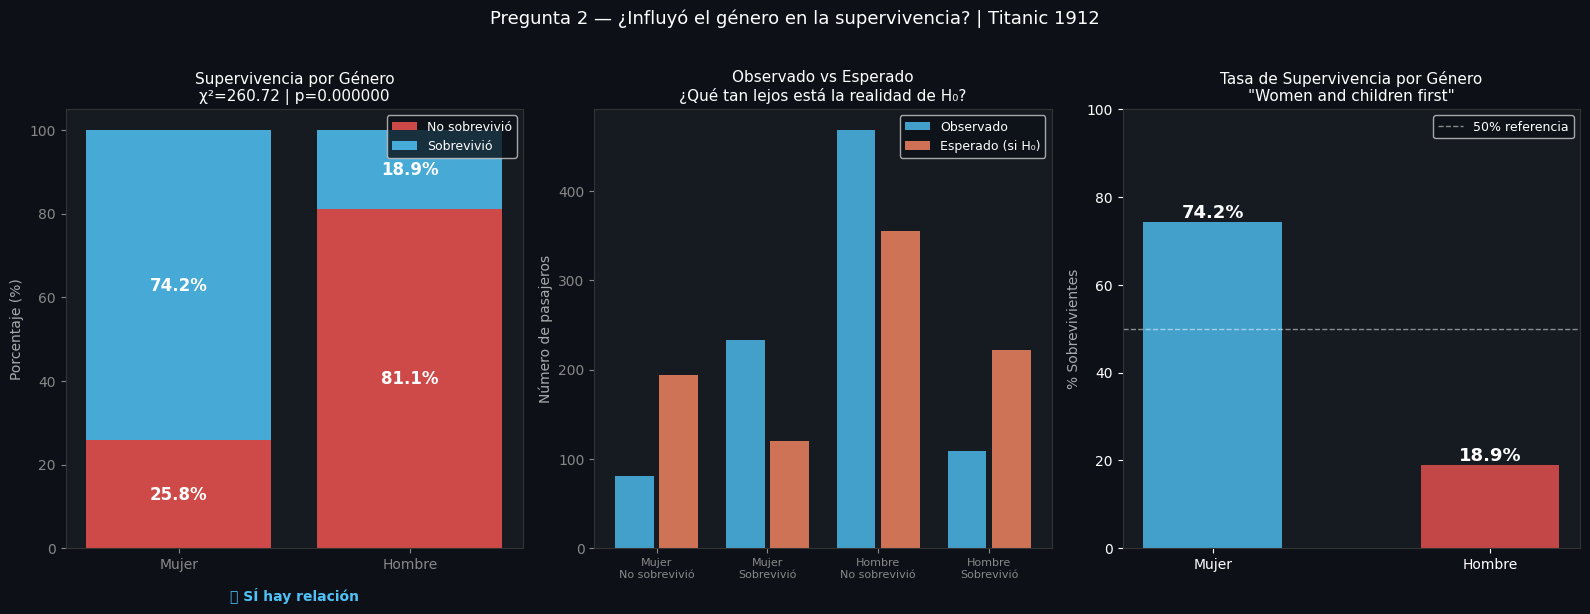

In [11]:
# ============================================================
# PREGUNTA 2 — CHI-CUADRADO: Género vs Supervivencia
# ============================================================
tabla = pd.crosstab(df['Sex'], df['Survived'])
chi2, p_chi, dof, expected = stats.chi2_contingency(tabla)

print(f"TABLA DE CONTINGENCIA:")
print(tabla)
print(f"\nValores ESPERADOS si no hubiera relación:")
print(pd.DataFrame(expected.round(1),
                   index=['female','male'],
                   columns=['No sobrevivió','Sobrevivió']))

conclusion = "✅ SÍ hay relación" if p_chi < 0.05 else "❌ NO hay relación"
print(f"\n{'='*50}")
print(f"CHI-CUADRADO")
print(f"{'='*50}")
print(f"χ²      : {chi2:.4f}")
print(f"p-value : {p_chi:.8f}")
print(f"Grados de libertad: {dof}")
print(f"Conclusión: {conclusion}")

tasa = df.groupby('Sex')['Survived'].mean() * 100
print(f"\nTasa de supervivencia:")
print(f"  Mujeres : {tasa['female']:.1f}%")
print(f"  Hombres : {tasa['male']:.1f}%")

# ============================================================
# VISUALIZACIÓN
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.patch.set_facecolor('#0d1117')

# --- Gráfica 1: Barras apiladas 100% ---
ax1 = axes[0]
ax1.set_facecolor('#161b22')

prop = tabla.div(tabla.sum(axis=1), axis=0) * 100
colores = ['#EF5350', '#4FC3F7']
bottom = np.zeros(len(prop))

for i, col in enumerate(prop.columns):
    label = 'No sobrevivió' if col == 0 else 'Sobrevivió'
    bars = ax1.bar(prop.index, prop[col], bottom=bottom,
                   color=colores[i], alpha=0.85, label=label)
    for bar, val in zip(bars, prop[col]):
        ax1.text(bar.get_x() + bar.get_width()/2,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', ha='center', va='center',
                 color='white', fontweight='bold', fontsize=12)
    bottom += prop[col].values

ax1.set_title(f'Supervivencia por Género\nχ²={chi2:.2f} | p={p_chi:.6f}',
              color='white', fontsize=11)
ax1.set_ylabel('Porcentaje (%)', color='#aaa')
ax1.set_xticklabels(['Mujer', 'Hombre'], color='white')
ax1.legend(facecolor='#0d1117', labelcolor='white', fontsize=9)
ax1.tick_params(colors='#888')
for spine in ax1.spines.values():
    spine.set_edgecolor('#333')
ax1.text(0.5, -0.12, conclusion, transform=ax1.transAxes,
         ha='center', color='#4FC3F7', fontsize=10, fontweight='bold')

# --- Gráfica 2: Observados vs Esperados ---
ax2 = axes[1]
ax2.set_facecolor('#161b22')

categorias = ['Mujer\nNo sobrevivió', 'Mujer\nSobrevivió',
              'Hombre\nNo sobrevivió', 'Hombre\nSobrevivió']
observados = [tabla.iloc[0,0], tabla.iloc[0,1],
              tabla.iloc[1,0], tabla.iloc[1,1]]
esperados  = [expected[0,0], expected[0,1],
              expected[1,0], expected[1,1]]

x = np.arange(len(categorias))
ax2.bar(x - 0.2, observados, width=0.35, color='#4FC3F7',
        alpha=0.8, label='Observado')
ax2.bar(x + 0.2, esperados,  width=0.35, color='#FF8A65',
        alpha=0.8, label='Esperado (si H₀)')

ax2.set_xticks(x)
ax2.set_xticklabels(categorias, color='white', fontsize=8)
ax2.set_title('Observado vs Esperado\n¿Qué tan lejos está la realidad de H₀?',
              color='white', fontsize=11)
ax2.set_ylabel('Número de pasajeros', color='#aaa')
ax2.legend(facecolor='#0d1117', labelcolor='white', fontsize=9)
ax2.tick_params(colors='#888')
for spine in ax2.spines.values():
    spine.set_edgecolor('#333')

# --- Gráfica 3: Tasas de supervivencia ---
ax3 = axes[2]
ax3.set_facecolor('#161b22')

generos  = ['Mujer', 'Hombre']
tasas    = [tasa['female'], tasa['male']]
colores3 = ['#4FC3F7', '#EF5350']

bars = ax3.bar(generos, tasas, color=colores3, alpha=0.8, width=0.5)
for bar, val in zip(bars, tasas):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'{val:.1f}%', ha='center', color='white',
             fontweight='bold', fontsize=13)

ax3.axhline(50, color='white', linestyle='--',
            linewidth=1, alpha=0.5, label='50% referencia')
ax3.set_title('Tasa de Supervivencia por Género\n"Women and children first"',
              color='white', fontsize=11)
ax3.set_ylabel('% Sobrevivientes', color='#aaa')
ax3.set_ylim(0, 100)
ax3.legend(facecolor='#0d1117', labelcolor='white', fontsize=9)
ax3.tick_params(colors='white')
for spine in ax3.spines.values():
    spine.set_edgecolor('#333')

plt.suptitle('Pregunta 2 — ¿Influyó el género en la supervivencia? | Titanic 1912',
             color='white', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


T-TEST — Tarifa por Supervivencia
Sobrevivió     — Media: £48.40  IC: £41.31 – £55.48
No sobrevivió  — Media: £22.12  IC: £19.49 – £24.75

t-statistic : 7.9392
p-value     : 0.00000000
Conclusión  : ✅ Diferencia SIGNIFICATIVA


/tmp/ipykernel_5435/695407164.py:126: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


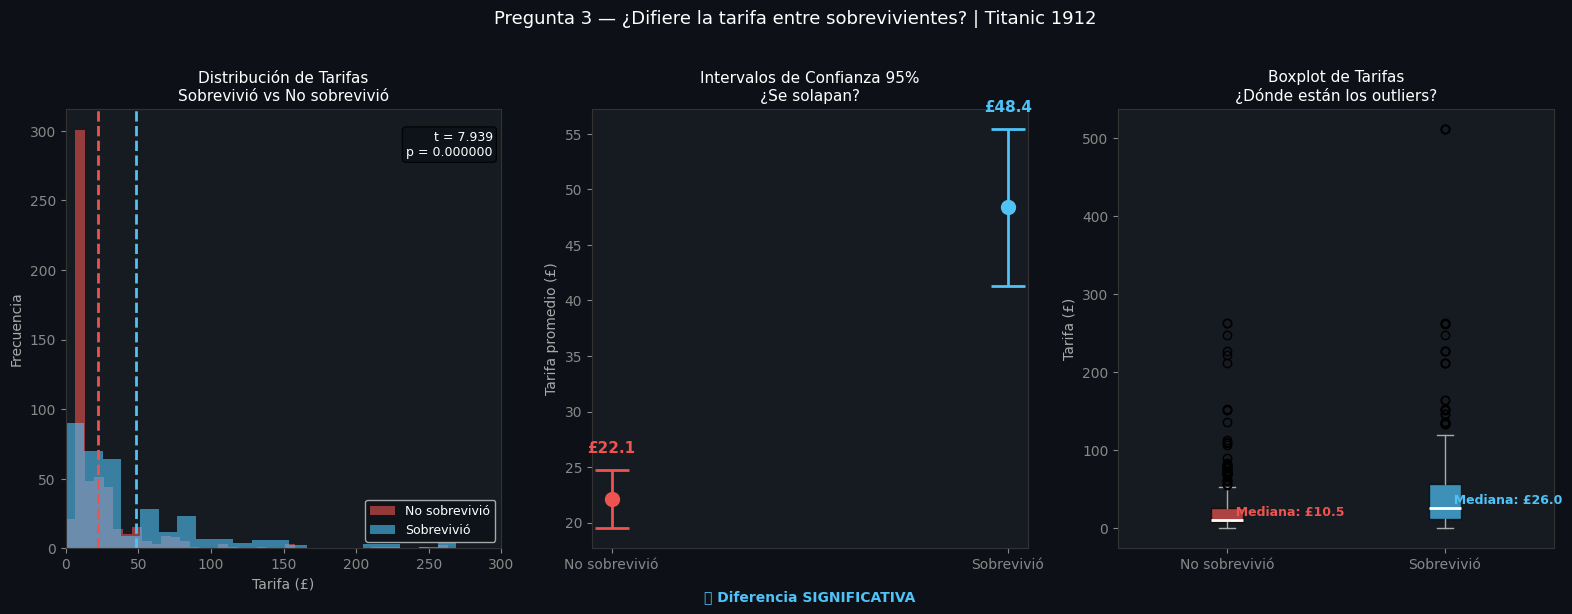

In [12]:
# ============================================================
# PREGUNTA 3 — T-TEST: Tarifa vs Supervivencia
# ============================================================
sobrevivio    = df[df['Survived'] == 1]['Fare'].dropna()
no_sobrevivio = df[df['Survived'] == 0]['Fare'].dropna()

# T-test
t_stat, p_ttest = stats.ttest_ind(sobrevivio, no_sobrevivio)

# Intervalos de confianza
def intervalo_confianza(data, confianza=0.95):
    n      = len(data)
    media  = np.mean(data)
    se     = stats.sem(data)
    ic     = stats.t.interval(confianza, df=n-1, loc=media, scale=se)
    return media, ic

media_s,  ic_s  = intervalo_confianza(sobrevivio)
media_ns, ic_ns = intervalo_confianza(no_sobrevivio)

conclusion = "✅ Diferencia SIGNIFICATIVA" if p_ttest < 0.05 else "❌ No significativa"

print(f"{'='*50}")
print(f"T-TEST — Tarifa por Supervivencia")
print(f"{'='*50}")
print(f"Sobrevivió     — Media: £{media_s:.2f}  IC: £{ic_s[0]:.2f} – £{ic_s[1]:.2f}")
print(f"No sobrevivió  — Media: £{media_ns:.2f}  IC: £{ic_ns[0]:.2f} – £{ic_ns[1]:.2f}")
print(f"\nt-statistic : {t_stat:.4f}")
print(f"p-value     : {p_ttest:.8f}")
print(f"Conclusión  : {conclusion}")

# ============================================================
# VISUALIZACIÓN
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.patch.set_facecolor('#0d1117')

# --- Gráfica 1: Distribución de tarifas ---
ax1 = axes[0]
ax1.set_facecolor('#161b22')

ax1.hist(no_sobrevivio, bins=40, color='#EF5350',
         alpha=0.6, label='No sobrevivió', edgecolor='none')
ax1.hist(sobrevivio,    bins=40, color='#4FC3F7',
         alpha=0.6, label='Sobrevivió', edgecolor='none')
ax1.axvline(media_ns, color='#EF5350', linestyle='--', linewidth=2)
ax1.axvline(media_s,  color='#4FC3F7', linestyle='--', linewidth=2)

ax1.set_title('Distribución de Tarifas\nSobrevivió vs No sobrevivió',
              color='white', fontsize=11)
ax1.set_xlabel('Tarifa (£)', color='#aaa')
ax1.set_ylabel('Frecuencia', color='#aaa')
ax1.legend(facecolor='#0d1117', labelcolor='white', fontsize=9)
ax1.tick_params(colors='#888')
for spine in ax1.spines.values():
    spine.set_edgecolor('#333')
ax1.set_xlim(0, 300)
ax1.text(0.98, 0.95,
         f't = {t_stat:.3f}\np = {p_ttest:.6f}',
         transform=ax1.transAxes, color='white', fontsize=9,
         ha='right', va='top',
         bbox=dict(boxstyle='round', facecolor='#0d1117', alpha=0.8))

# --- Gráfica 2: Intervalos de confianza ---
ax2 = axes[1]
ax2.set_facecolor('#161b22')

grupos  = ['No sobrevivió', 'Sobrevivió']
medias  = [media_ns, media_s]
ics     = [ic_ns, ic_s]
colores = ['#EF5350', '#4FC3F7']

for i, (grupo, media, ic, color) in enumerate(
        zip(grupos, medias, ics, colores)):
    ax2.errorbar(i, media,
                 yerr=[[media - ic[0]], [ic[1] - media]],
                 fmt='o', color=color, capsize=12,
                 capthick=2, markersize=10, linewidth=2)
    ax2.text(i, ic[1] + 1.5,
             f'£{media:.1f}', ha='center',
             color=color, fontsize=11, fontweight='bold')

ax2.set_xticks([0, 1])
ax2.set_xticklabels(grupos, color='white')
ax2.set_title('Intervalos de Confianza 95%\n¿Se solapan?',
              color='white', fontsize=11)
ax2.set_ylabel('Tarifa promedio (£)', color='#aaa')
ax2.tick_params(colors='#888')
for spine in ax2.spines.values():
    spine.set_edgecolor('#333')
ax2.text(0.5, -0.12, conclusion, transform=ax2.transAxes,
         ha='center', color='#4FC3F7', fontsize=10, fontweight='bold')

# --- Gráfica 3: Boxplot con outliers ---
ax3 = axes[2]
ax3.set_facecolor('#161b22')

bp = ax3.boxplot([no_sobrevivio, sobrevivio],
                 patch_artist=True,
                 medianprops=dict(color='white', linewidth=2))

for patch, color in zip(bp['boxes'], ['#EF5350', '#4FC3F7']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
for element in ['whiskers', 'caps', 'fliers']:
    for item in bp[element]:
        item.set_color('#aaa')

for i, (grupo, color) in enumerate(
        zip([no_sobrevivio, sobrevivio], ['#EF5350', '#4FC3F7']), 1):
    ax3.text(i, grupo.median() + 2,
             f'  Mediana: £{grupo.median():.1f}',
             va='bottom', color=color, fontsize=9, fontweight='bold')

ax3.set_xticks([1, 2])
ax3.set_xticklabels(['No sobrevivió', 'Sobrevivió'], color='white')
ax3.set_title('Boxplot de Tarifas\n¿Dónde están los outliers?',
              color='white', fontsize=11)
ax3.set_ylabel('Tarifa (£)', color='#aaa')
ax3.tick_params(colors='#888')
for spine in ax3.spines.values():
    spine.set_edgecolor('#333')

plt.suptitle('Pregunta 3 — ¿Difiere la tarifa entre sobrevivientes? | Titanic 1912',
             color='white', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


ANOVA — Tarifa por Clase
1ª Clase — Media: £84.15 | Mediana: £60.29
2ª Clase — Media: £20.66 | Mediana: £14.25
3ª Clase — Media: £13.68 | Mediana: £8.05

F-statistic : 242.3442
p-value     : 0.00000000
Conclusión  : ✅ Al menos una clase difiere

TUKEY — Comparaciones por par
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj  lower    upper   reject
-----------------------------------------------------
     1      2 -63.4925   0.0 -72.9165 -54.0685   True
     1      3 -70.4791   0.0 -78.1489 -62.8094   True
     2      3  -6.9866 0.108 -15.1064   1.1331  False
-----------------------------------------------------


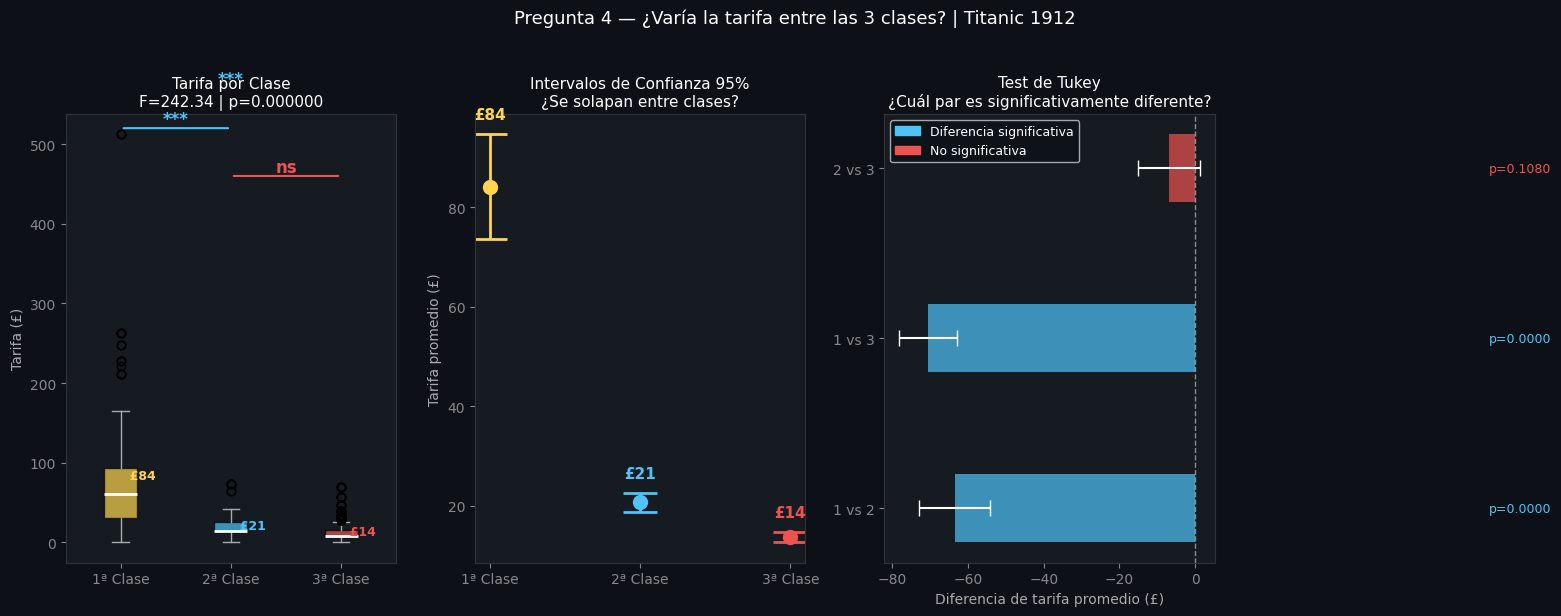

In [13]:
# ============================================================
# PREGUNTA 4 — ANOVA + TUKEY: Tarifa por Clase
# ============================================================
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Separar grupos
clase1 = df[df['Pclass'] == 1]['Fare'].dropna()
clase2 = df[df['Pclass'] == 2]['Fare'].dropna()
clase3 = df[df['Pclass'] == 3]['Fare'].dropna()

# ANOVA
f_stat, p_anova = stats.f_oneway(clase1, clase2, clase3)

# Tukey
df_tukey = df[['Pclass', 'Fare']].dropna()
df_tukey['Pclass'] = df_tukey['Pclass'].astype(str)
tukey = pairwise_tukeyhsd(endog=df_tukey['Fare'],
                          groups=df_tukey['Pclass'],
                          alpha=0.05)
tukey_df = pd.DataFrame(data=tukey._results_table.data[1:],
                        columns=tukey._results_table.data[0])

conclusion_anova = "✅ Al menos una clase difiere" if p_anova < 0.05 else "❌ No hay diferencia"

print(f"{'='*50}")
print(f"ANOVA — Tarifa por Clase")
print(f"{'='*50}")
print(f"1ª Clase — Media: £{clase1.mean():.2f} | Mediana: £{clase1.median():.2f}")
print(f"2ª Clase — Media: £{clase2.mean():.2f} | Mediana: £{clase2.median():.2f}")
print(f"3ª Clase — Media: £{clase3.mean():.2f} | Mediana: £{clase3.median():.2f}")
print(f"\nF-statistic : {f_stat:.4f}")
print(f"p-value     : {p_anova:.8f}")
print(f"Conclusión  : {conclusion_anova}")
print(f"\n{'='*50}")
print(f"TUKEY — Comparaciones por par")
print(f"{'='*50}")
print(tukey)

# ============================================================
# VISUALIZACIÓN
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.patch.set_facecolor('#0d1117')

colores_clase = ['#FFD54F', '#4FC3F7', '#EF5350']
nombres_clase = ['1ª Clase', '2ª Clase', '3ª Clase']
grupos        = [clase1, clase2, clase3]

# --- Gráfica 1: Boxplot por clase ---
ax1 = axes[0]
ax1.set_facecolor('#161b22')

bp = ax1.boxplot(grupos, patch_artist=True,
                 medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], colores_clase):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
for element in ['whiskers', 'caps', 'fliers']:
    for item in bp[element]:
        item.set_color('#aaa')

# Anotaciones de significancia Tukey
pares_idx = [(1,2), (1,3), (2,3)]
alturas   = [520, 570, 460]
for (g1, g2), altura, (_, row) in zip(pares_idx, alturas, tukey_df.iterrows()):
    p_adj = float(row['p-adj'])
    sig   = '***' if p_adj < 0.001 else ('*' if p_adj < 0.05 else 'ns')
    color_sig = '#4FC3F7' if sig != 'ns' else '#EF5350'
    ax1.annotate('', xy=(g2, altura), xytext=(g1, altura),
                 arrowprops=dict(arrowstyle='-', color=color_sig, lw=1.5))
    ax1.text((g1+g2)/2, altura+5, sig,
             ha='center', color=color_sig, fontsize=12, fontweight='bold')

for i, (grupo, color) in enumerate(zip(grupos, colores_clase), 1):
    ax1.text(i, grupo.mean(),
             f'  £{grupo.mean():.0f}',
             va='center', color=color, fontsize=9, fontweight='bold')

ax1.set_xticks([1, 2, 3])
ax1.set_xticklabels(nombres_clase, color='white')
ax1.set_title(f'Tarifa por Clase\nF={f_stat:.2f} | p={p_anova:.6f}',
              color='white', fontsize=11)
ax1.set_ylabel('Tarifa (£)', color='#aaa')
ax1.tick_params(colors='#888')
for spine in ax1.spines.values():
    spine.set_edgecolor('#333')

# --- Gráfica 2: Medias con intervalos de confianza ---
ax2 = axes[1]
ax2.set_facecolor('#161b22')

for i, (grupo, color, nombre) in enumerate(
        zip(grupos, colores_clase, nombres_clase)):
    media, ic = intervalo_confianza(grupo)
    ax2.errorbar(i, media,
                 yerr=[[media - ic[0]], [ic[1] - media]],
                 fmt='o', color=color, capsize=12,
                 capthick=2, markersize=10, linewidth=2)
    ax2.text(i, ic[1] + 3,
             f'£{media:.0f}', ha='center',
             color=color, fontsize=11, fontweight='bold')

ax2.set_xticks([0, 1, 2])
ax2.set_xticklabels(nombres_clase, color='white')
ax2.set_title('Intervalos de Confianza 95%\n¿Se solapan entre clases?',
              color='white', fontsize=11)
ax2.set_ylabel('Tarifa promedio (£)', color='#aaa')
ax2.tick_params(colors='#888')
for spine in ax2.spines.values():
    spine.set_edgecolor('#333')

# --- Gráfica 3: Tukey diferencias ---
ax3 = axes[2]
ax3.set_facecolor('#161b22')

pares   = [f"{r['group1']} vs {r['group2']}" for _, r in tukey_df.iterrows()]
diffs   = tukey_df['meandiff'].astype(float).values
lowers  = tukey_df['lower'].astype(float).values
uppers  = tukey_df['upper'].astype(float).values
rechaza = tukey_df['reject'].astype(str).values
padjs   = tukey_df['p-adj'].astype(float).values

colores_t = ['#4FC3F7' if r == 'True' else '#EF5350' for r in rechaza]

for i, (par, diff, low, up, color, p) in enumerate(
        zip(pares, diffs, lowers, uppers, colores_t, padjs)):
    ax3.barh(i, diff, color=color, alpha=0.7, height=0.4)
    ax3.errorbar(diff, i,
                 xerr=[[diff-low], [up-diff]],
                 fmt='none', color='white', capsize=6, linewidth=1.5)
    ax3.text(max(abs(diffs))*1.1, i,
             f'p={p:.4f}', va='center', color=color, fontsize=9)

ax3.axvline(0, color='white', linestyle='--', linewidth=1, alpha=0.5)
ax3.set_yticks(range(len(pares)))
ax3.set_yticklabels(pares, color='white', fontsize=10)
ax3.set_xlabel('Diferencia de tarifa promedio (£)', color='#aaa')
ax3.set_title('Test de Tukey\n¿Cuál par es significativamente diferente?',
              color='white', fontsize=11)
ax3.tick_params(colors='#888')
for spine in ax3.spines.values():
    spine.set_edgecolor('#333')

from matplotlib.patches import Patch
leyenda = [Patch(color='#4FC3F7', label='Diferencia significativa'),
           Patch(color='#EF5350', label='No significativa')]
ax3.legend(handles=leyenda, facecolor='#0d1117',
           labelcolor='white', fontsize=9)

plt.suptitle('Pregunta 4 — ¿Varía la tarifa entre las 3 clases? | Titanic 1912',
             color='white', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

CORRELACIÓN DE PEARSON — Edad vs Tarifa
r       : 0.1004
p-value : 0.007383
Conclusión: ✅ Correlación significativa
Fuerza  : Correlación débil

REGRESIÓN LINEAL
Ecuación : Tarifa = 23.89 + 0.30 × Edad
R²       : 0.0101 → explica 1.0% de la variación
MAE      : £27.24 error promedio por predicción

Predicciones:
  Pasajero de 10 años → £26.85
  Pasajero de 25 años → £31.29
  Pasajero de 45 años → £37.22
  Pasajero de 65 años → £43.14


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


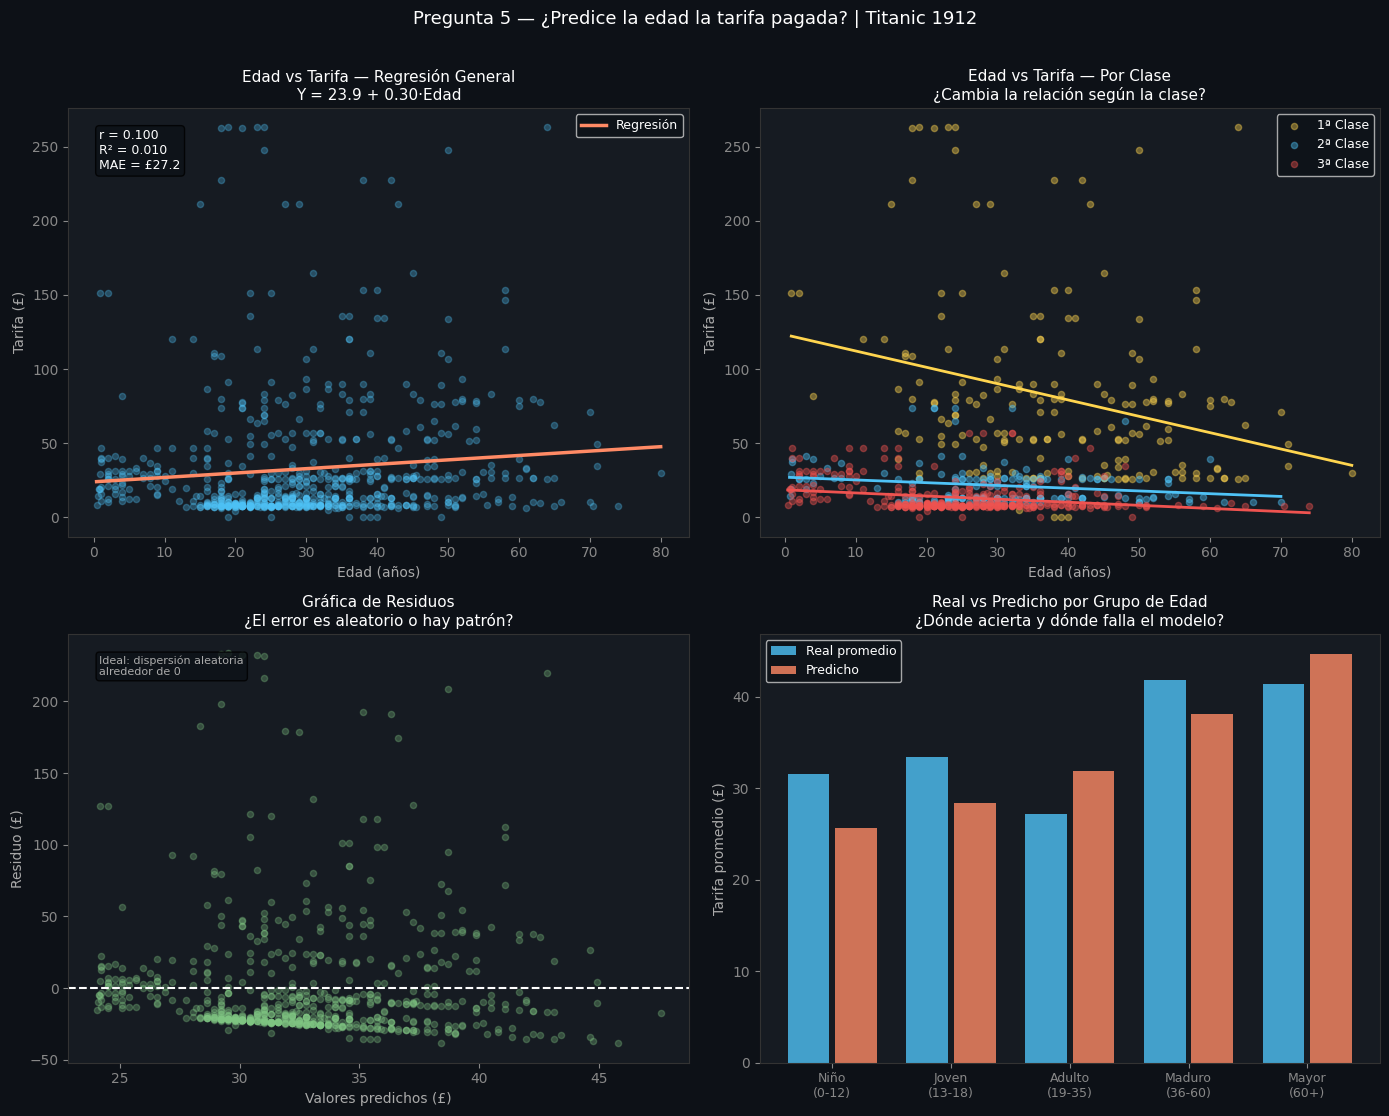

In [14]:
# ============================================================
# PREGUNTA 5 — CORRELACIÓN Y REGRESIÓN: Edad vs Tarifa
# ============================================================
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# Dataset limpio para este análisis
df_reg = df[['Age', 'Fare', 'Pclass']].dropna()
df_reg = df_reg[df_reg['Fare'] < 300]  # removemos outliers extremos

X = df_reg[['Age']]
y = df_reg['Fare']

# Correlación
corr, p_corr = stats.pearsonr(df_reg['Age'], df_reg['Fare'])

# Regresión
modelo = LinearRegression()
modelo.fit(X, y)
y_pred = modelo.predict(X)
r2     = r2_score(y, y_pred)
mae    = mean_absolute_error(y, y_pred)
beta0  = modelo.intercept_
beta1  = modelo.coef_[0]

# Residuos
residuos = y - y_pred

conclusion_corr = "✅ Correlación significativa" if p_corr < 0.05 else "❌ No significativa"

print(f"{'='*50}")
print(f"CORRELACIÓN DE PEARSON — Edad vs Tarifa")
print(f"{'='*50}")
print(f"r       : {corr:.4f}")
print(f"p-value : {p_corr:.6f}")
print(f"Conclusión: {conclusion_corr}")
fuerza = 'fuerte' if abs(corr) > 0.7 else 'moderada' if abs(corr) > 0.4 else 'débil'
print(f"Fuerza  : Correlación {fuerza}")

print(f"\n{'='*50}")
print(f"REGRESIÓN LINEAL")
print(f"{'='*50}")
print(f"Ecuación : Tarifa = {beta0:.2f} + {beta1:.2f} × Edad")
print(f"R²       : {r2:.4f} → explica {r2*100:.1f}% de la variación")
print(f"MAE      : £{mae:.2f} error promedio por predicción")
print(f"\nPredicciones:")
for edad in [10, 25, 45, 65]:
    print(f"  Pasajero de {edad} años → £{beta0 + beta1*edad:.2f}")

# ============================================================
# VISUALIZACIÓN
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.patch.set_facecolor('#0d1117')

# --- Gráfica 1: Scatter + regresión general ---
ax1 = axes[0, 0]
ax1.set_facecolor('#161b22')

ax1.scatter(df_reg['Age'], df_reg['Fare'],
            color='#4FC3F7', alpha=0.3, s=20)
x_line = np.linspace(df_reg['Age'].min(), df_reg['Age'].max(), 100)
ax1.plot(x_line, beta0 + beta1*x_line,
         color='#FF8A65', linewidth=2.5, label='Regresión')

ax1.set_title(f'Edad vs Tarifa — Regresión General\n'
              f'Y = {beta0:.1f} + {beta1:.2f}·Edad',
              color='white', fontsize=11)
ax1.set_xlabel('Edad (años)', color='#aaa')
ax1.set_ylabel('Tarifa (£)', color='#aaa')
ax1.legend(facecolor='#0d1117', labelcolor='white', fontsize=9)
ax1.tick_params(colors='#888')
for spine in ax1.spines.values():
    spine.set_edgecolor('#333')
ax1.text(0.05, 0.95,
         f'r = {corr:.3f}\nR² = {r2:.3f}\nMAE = £{mae:.1f}',
         transform=ax1.transAxes, color='white', fontsize=9,
         va='top', bbox=dict(boxstyle='round',
         facecolor='#0d1117', alpha=0.8))

# --- Gráfica 2: Scatter por clase ---
ax2 = axes[0, 1]
ax2.set_facecolor('#161b22')

colores_clase = {1: '#FFD54F', 2: '#4FC3F7', 3: '#EF5350'}
for clase in [1, 2, 3]:
    sub = df_reg[df_reg['Pclass'] == clase]
    ax2.scatter(sub['Age'], sub['Fare'],
                color=colores_clase[clase], alpha=0.4,
                s=20, label=f'{clase}ª Clase')
    m = LinearRegression()
    m.fit(sub[['Age']], sub['Fare'])
    x_c = np.linspace(sub['Age'].min(), sub['Age'].max(), 50)
    ax2.plot(x_c, m.predict(x_c.reshape(-1,1)),
             color=colores_clase[clase], linewidth=2)

ax2.set_title('Edad vs Tarifa — Por Clase\n'
              '¿Cambia la relación según la clase?',
              color='white', fontsize=11)
ax2.set_xlabel('Edad (años)', color='#aaa')
ax2.set_ylabel('Tarifa (£)', color='#aaa')
ax2.legend(facecolor='#0d1117', labelcolor='white', fontsize=9)
ax2.tick_params(colors='#888')
for spine in ax2.spines.values():
    spine.set_edgecolor('#333')

# --- Gráfica 3: Residuos ---
ax3 = axes[1, 0]
ax3.set_facecolor('#161b22')

ax3.scatter(y_pred, residuos, color='#81C784', alpha=0.3, s=20)
ax3.axhline(0, color='white', linestyle='--', linewidth=1.5)
ax3.set_title('Gráfica de Residuos\n'
              '¿El error es aleatorio o hay patrón?',
              color='white', fontsize=11)
ax3.set_xlabel('Valores predichos (£)', color='#aaa')
ax3.set_ylabel('Residuo (£)', color='#aaa')
ax3.tick_params(colors='#888')
for spine in ax3.spines.values():
    spine.set_edgecolor('#333')
ax3.text(0.05, 0.95,
         'Ideal: dispersión aleatoria\nalrededor de 0',
         transform=ax3.transAxes, color='#aaa', fontsize=8,
         va='top', bbox=dict(boxstyle='round',
         facecolor='#0d1117', alpha=0.8))

# --- Gráfica 4: Real vs Predicho por grupo de edad ---
ax4 = axes[1, 1]
ax4.set_facecolor('#161b22')

df_reg['grupo_edad'] = pd.cut(df_reg['Age'],
                               bins=[0, 12, 18, 35, 60, 100],
                               labels=['Niño\n(0-12)', 'Joven\n(13-18)',
                                       'Adulto\n(19-35)', 'Maduro\n(36-60)',
                                       'Mayor\n(60+)'])
medias_reales = df_reg.groupby('grupo_edad', observed=True)['Fare'].mean()
pred_grupos   = {
    'Niño\n(0-12)'  : beta0 + beta1 * 6,
    'Joven\n(13-18)': beta0 + beta1 * 15,
    'Adulto\n(19-35)': beta0 + beta1 * 27,
    'Maduro\n(36-60)': beta0 + beta1 * 48,
    'Mayor\n(60+)'  : beta0 + beta1 * 70,
}

x_pos = np.arange(len(medias_reales))
ax4.bar(x_pos - 0.2, medias_reales.values, width=0.35,
        color='#4FC3F7', alpha=0.8, label='Real promedio')
ax4.bar(x_pos + 0.2, list(pred_grupos.values()), width=0.35,
        color='#FF8A65', alpha=0.8, label='Predicho')

ax4.set_xticks(x_pos)
ax4.set_xticklabels(medias_reales.index, color='white', fontsize=9)
ax4.set_title('Real vs Predicho por Grupo de Edad\n'
              '¿Dónde acierta y dónde falla el modelo?',
              color='white', fontsize=11)
ax4.set_ylabel('Tarifa promedio (£)', color='#aaa')
ax4.legend(facecolor='#0d1117', labelcolor='white', fontsize=9)
ax4.tick_params(colors='#888')
for spine in ax4.spines.values():
    spine.set_edgecolor('#333')

plt.suptitle('Pregunta 5 — ¿Predice la edad la tarifa pagada? | Titanic 1912',
             color='white', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

/tmp/ipykernel_5435/413134059.py:98: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(['Female', 'Male'], color='white')


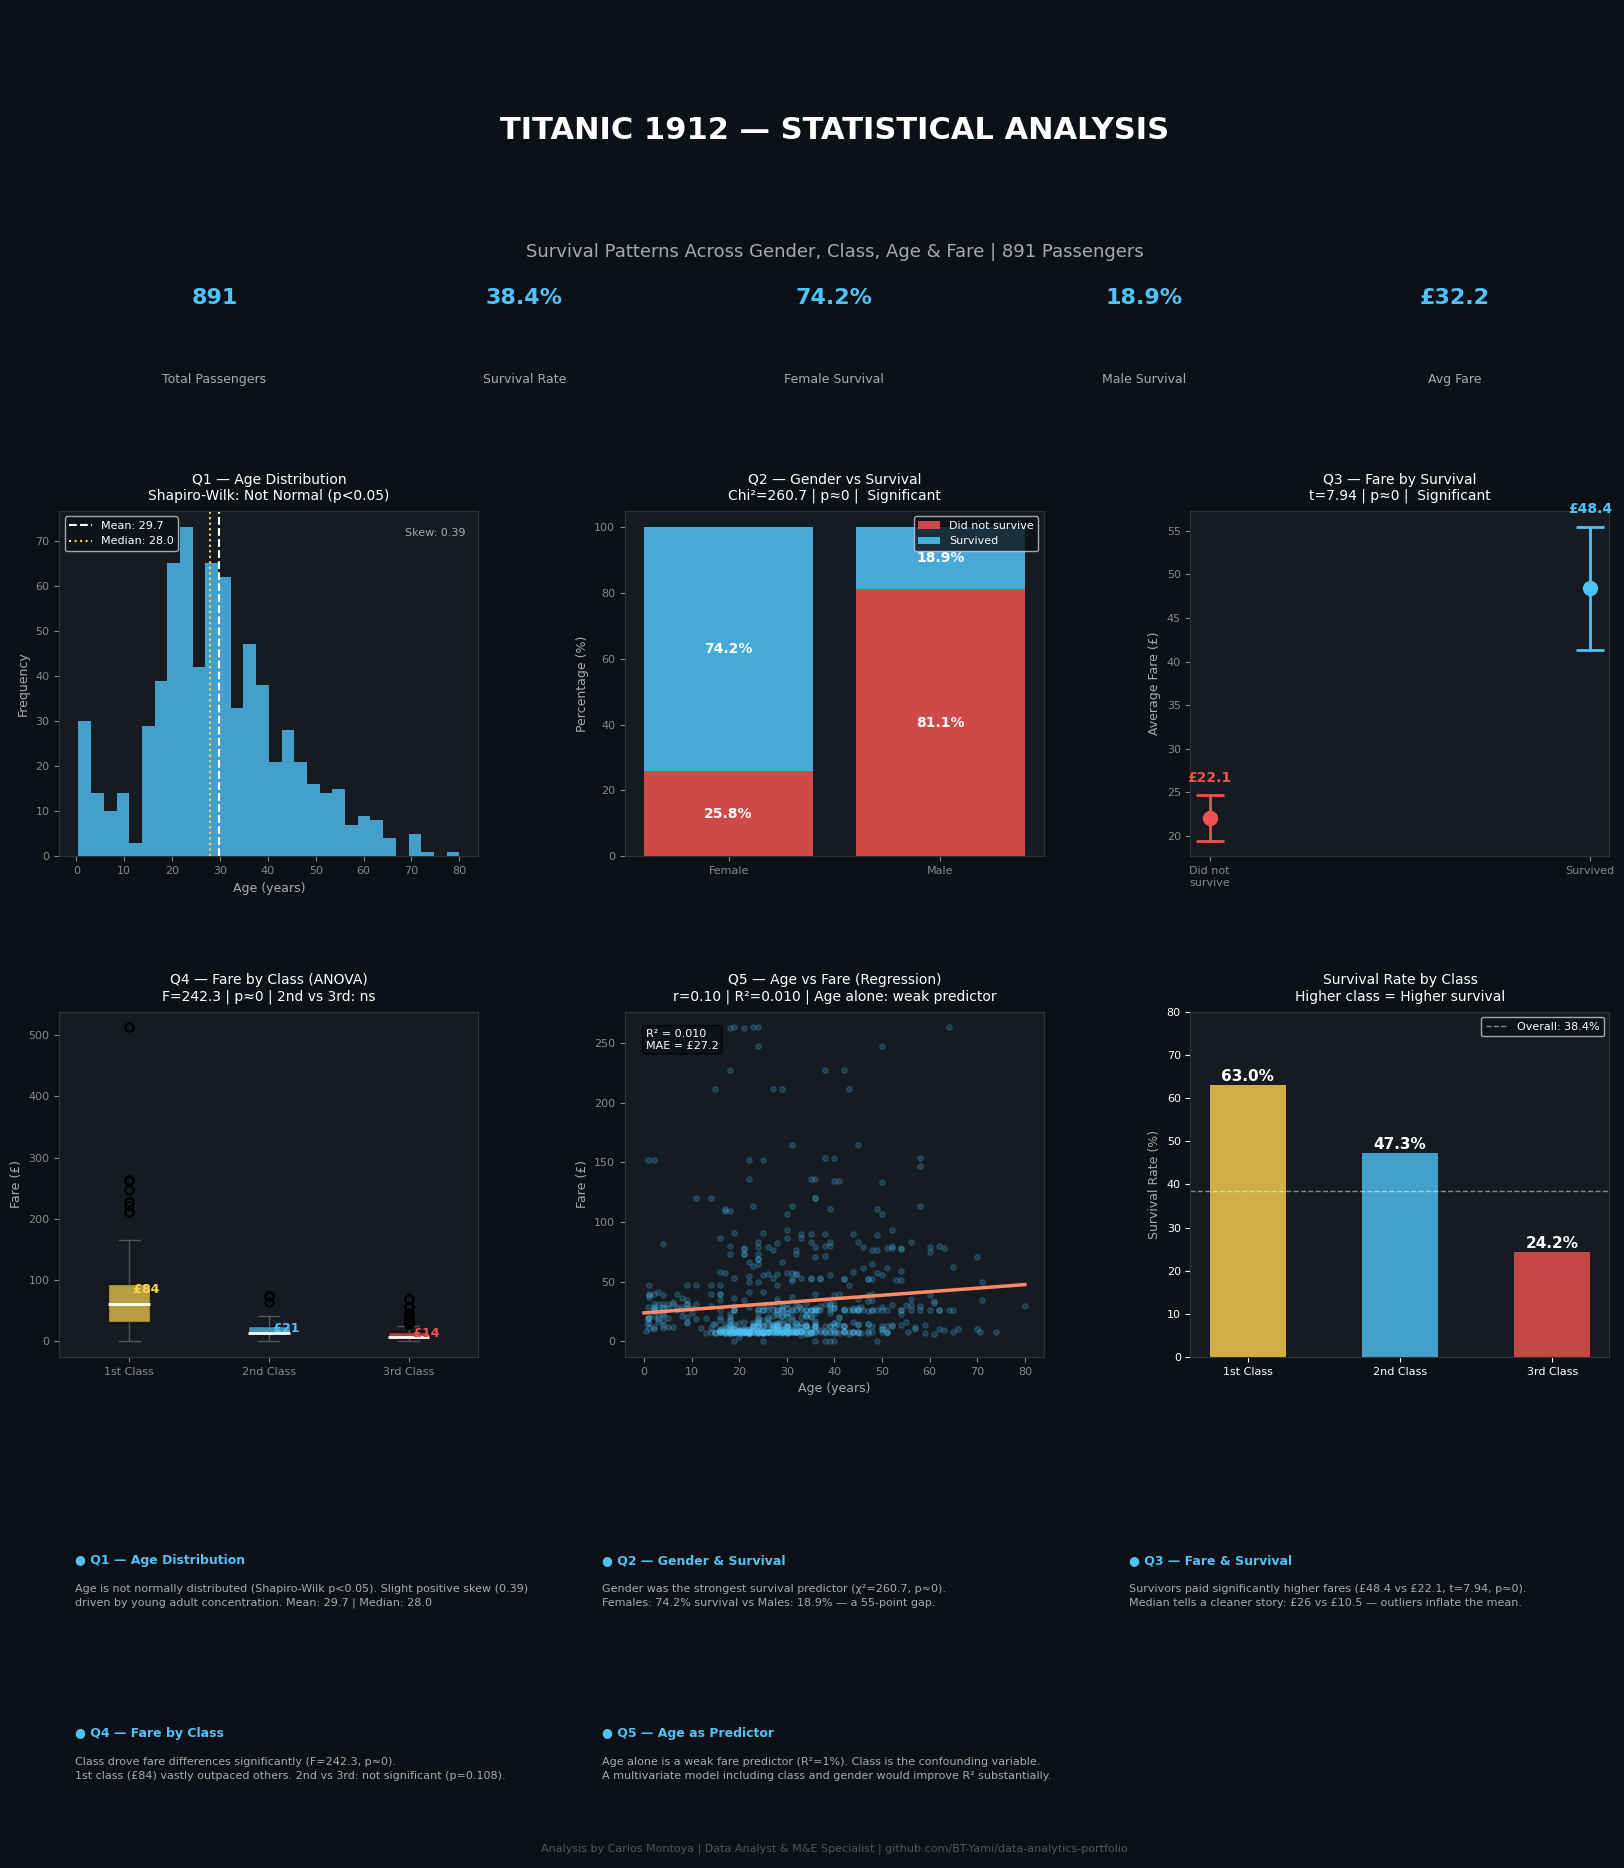

✅ Dashboard saved as 'titanic_statistical_analysis.png'


In [18]:
# ============================================================
# FINAL EXECUTIVE DASHBOARD
# Titanic 1912 — Complete Statistical Analysis
# ============================================================
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(20, 24))
fig.patch.set_facecolor('#0d1117')

gs = gridspec.GridSpec(4, 3, figure=fig,
                       hspace=0.45, wspace=0.35)

# ============================================================
# HEADER
# ============================================================
ax_title = fig.add_subplot(gs[0, :])
ax_title.set_facecolor('#161b22')
ax_title.text(0.5, 0.65,
              'TITANIC 1912 — STATISTICAL ANALYSIS',
              ha='center', va='center', color='white',
              fontsize=22, fontweight='bold')
ax_title.text(0.5, 0.30,
              'Survival Patterns Across Gender, Class, Age & Fare | 891 Passengers',
              ha='center', va='center', color='#aaa', fontsize=13)

# KPIs
kpis = [
    ('891', 'Total Passengers'),
    ('38.4%', 'Survival Rate'),
    ('74.2%', 'Female Survival'),
    ('18.9%', 'Male Survival'),
    ('£32.2', 'Avg Fare'),
]
for i, (val, label) in enumerate(kpis):
    x = 0.1 + i * 0.2
    ax_title.text(x, 0.15, val, ha='center', color='#4FC3F7',
                  fontsize=16, fontweight='bold',
                  transform=ax_title.transAxes)
    ax_title.text(x, -0.08, label, ha='center', color='#aaa',
                  fontsize=9, transform=ax_title.transAxes)

ax_title.axis('off')
for spine in ax_title.spines.values():
    spine.set_edgecolor('#333')

# ============================================================
# PANEL 1 — Age Distribution (Q1)
# ============================================================
ax1 = fig.add_subplot(gs[1, 0])
ax1.set_facecolor('#161b22')

ax1.hist(df['Age'].dropna(), bins=30,
         color='#4FC3F7', alpha=0.8, edgecolor='none')
ax1.axvline(df['Age'].mean(), color='white',
            linestyle='--', linewidth=1.5,
            label=f"Mean: {df['Age'].mean():.1f}")
ax1.axvline(df['Age'].median(), color='#FFD54F',
            linestyle=':', linewidth=1.5,
            label=f"Median: {df['Age'].median():.1f}")

ax1.set_title('Q1 — Age Distribution\nShapiro-Wilk: Not Normal (p<0.05)',
              color='white', fontsize=10, pad=8)
ax1.set_xlabel('Age (years)', color='#aaa', fontsize=9)
ax1.set_ylabel('Frequency', color='#aaa', fontsize=9)
ax1.legend(facecolor='#0d1117', labelcolor='white', fontsize=8)
ax1.tick_params(colors='#888', labelsize=8)
ax1.text(0.97, 0.95, f'Skew: {df["Age"].dropna().skew():.2f}',
         transform=ax1.transAxes, color='#aaa', fontsize=8,
         ha='right', va='top')
for spine in ax1.spines.values():
    spine.set_edgecolor('#333')

# ============================================================
# PANEL 2 — Gender vs Survival Chi-square (Q2)
# ============================================================
ax2 = fig.add_subplot(gs[1, 1])
ax2.set_facecolor('#161b22')

tabla   = pd.crosstab(df['Sex'], df['Survived'])
chi2_v, p_chi_v, _, _ = stats.chi2_contingency(tabla)
prop    = tabla.div(tabla.sum(axis=1), axis=0) * 100
bottom  = np.zeros(len(prop))
colores_g = ['#EF5350', '#4FC3F7']

for i, col in enumerate(prop.columns):
    label = 'Did not survive' if col == 0 else 'Survived'
    bars  = ax2.bar(prop.index, prop[col], bottom=bottom,
                    color=colores_g[i], alpha=0.85, label=label)
    for bar, val in zip(bars, prop[col]):
        ax2.text(bar.get_x() + bar.get_width()/2,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', ha='center', va='center',
                 color='white', fontweight='bold', fontsize=10)
    bottom += prop[col].values

ax2.set_title(f'Q2 — Gender vs Survival\nChi²={chi2_v:.1f} | p≈0 |  Significant',
              color='white', fontsize=10, pad=8)
ax2.set_xticklabels(['Female', 'Male'], color='white')
ax2.set_ylabel('Percentage (%)', color='#aaa', fontsize=9)
ax2.legend(facecolor='#0d1117', labelcolor='white', fontsize=8)
ax2.tick_params(colors='#888', labelsize=8)
for spine in ax2.spines.values():
    spine.set_edgecolor('#333')

# ============================================================
# PANEL 3 — Fare by Survival t-test (Q3)
# ============================================================
ax3 = fig.add_subplot(gs[1, 2])
ax3.set_facecolor('#161b22')

surv     = df[df['Survived'] == 1]['Fare'].dropna()
no_surv  = df[df['Survived'] == 0]['Fare'].dropna()
t_v, p_t = stats.ttest_ind(surv, no_surv)

grupos_t  = ['Did not\nsurvive', 'Survived']
medias_t  = [no_surv.mean(), surv.mean()]
colores_t = ['#EF5350', '#4FC3F7']

def ic(data):
    return stats.t.interval(0.95, df=len(data)-1,
                            loc=np.mean(data), scale=stats.sem(data))

ic_ns = ic(no_surv)
ic_s  = ic(surv)
ics_t = [ic_ns, ic_s]

for i, (grupo, media, color, ic_val) in enumerate(
        zip(grupos_t, medias_t, colores_t, ics_t)):
    ax3.errorbar(i, media,
                 yerr=[[media - ic_val[0]], [ic_val[1] - media]],
                 fmt='o', color=color, capsize=10,
                 capthick=2, markersize=10, linewidth=2)
    ax3.text(i, ic_val[1] + 1.5, f'£{media:.1f}',
             ha='center', color=color,
             fontsize=10, fontweight='bold')

ax3.set_xticks([0, 1])
ax3.set_xticklabels(grupos_t, color='white', fontsize=9)
ax3.set_title(f'Q3 — Fare by Survival\nt={t_v:.2f} | p≈0 |  Significant',
              color='white', fontsize=10, pad=8)
ax3.set_ylabel('Average Fare (£)', color='#aaa', fontsize=9)
ax3.tick_params(colors='#888', labelsize=8)
for spine in ax3.spines.values():
    spine.set_edgecolor('#333')

# ============================================================
# PANEL 4 — ANOVA Fare by Class (Q4)
# ============================================================
ax4 = fig.add_subplot(gs[2, 0])
ax4.set_facecolor('#161b22')

c1 = df[df['Pclass'] == 1]['Fare'].dropna()
c2 = df[df['Pclass'] == 2]['Fare'].dropna()
c3 = df[df['Pclass'] == 3]['Fare'].dropna()
f_v, p_f = stats.f_oneway(c1, c2, c3)

bp = ax4.boxplot([c1, c2, c3], patch_artist=True,
                 medianprops=dict(color='white', linewidth=2))
cls_colors = ['#FFD54F', '#4FC3F7', '#EF5350']
for patch, color in zip(bp['boxes'], cls_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
for element in ['whiskers', 'caps', 'fliers']:
    for item in bp[element]:
        item.set_color('#555')

for i, (g, color) in enumerate(zip([c1, c2, c3], cls_colors), 1):
    ax4.text(i, g.mean(), f' £{g.mean():.0f}',
             va='center', color=color,
             fontsize=9, fontweight='bold')

ax4.set_xticks([1, 2, 3])
ax4.set_xticklabels(['1st Class', '2nd Class', '3rd Class'], color='white')
ax4.set_title(f'Q4 — Fare by Class (ANOVA)\nF={f_v:.1f} | p≈0 | 2nd vs 3rd: ns',
              color='white', fontsize=10, pad=8)
ax4.set_ylabel('Fare (£)', color='#aaa', fontsize=9)
ax4.tick_params(colors='#888', labelsize=8)
for spine in ax4.spines.values():
    spine.set_edgecolor('#333')

# ============================================================
# PANEL 5 — Regression Age vs Fare (Q5)
# ============================================================
ax5 = fig.add_subplot(gs[2, 1])
ax5.set_facecolor('#161b22')

df_r = df[['Age', 'Fare']].dropna()
df_r = df_r[df_r['Fare'] < 300]
corr_v, p_corr_v = stats.pearsonr(df_r['Age'], df_r['Fare'])

from sklearn.linear_model import LinearRegression
m = LinearRegression()
m.fit(df_r[['Age']], df_r['Fare'])
b0 = m.intercept_
b1 = m.coef_[0]
r2_v = r2_score(df_r['Fare'], m.predict(df_r[['Age']]))

ax5.scatter(df_r['Age'], df_r['Fare'],
            color='#4FC3F7', alpha=0.2, s=15)
x_l = np.linspace(0, 80, 100)
ax5.plot(x_l, b0 + b1*x_l,
         color='#FF8A65', linewidth=2.5)

ax5.set_title(f'Q5 — Age vs Fare (Regression)\nr={corr_v:.2f} | R²={r2_v:.3f} | Age alone: weak predictor',
              color='white', fontsize=10, pad=8)
ax5.set_xlabel('Age (years)', color='#aaa', fontsize=9)
ax5.set_ylabel('Fare (£)', color='#aaa', fontsize=9)
ax5.tick_params(colors='#888', labelsize=8)
ax5.text(0.05, 0.95,
         f'R² = {r2_v:.3f}\nMAE = £{mean_absolute_error(df_r["Fare"], m.predict(df_r[["Age"]])):.1f}',
         transform=ax5.transAxes, color='white', fontsize=8,
         va='top', bbox=dict(boxstyle='round',
         facecolor='#0d1117', alpha=0.8))
for spine in ax5.spines.values():
    spine.set_edgecolor('#333')

# ============================================================
# PANEL 6 — Survival Rate by Class
# ============================================================
ax6 = fig.add_subplot(gs[2, 2])
ax6.set_facecolor('#161b22')

surv_class = df.groupby('Pclass')['Survived'].mean() * 100
cls_names  = ['1st Class', '2nd Class', '3rd Class']
bars = ax6.bar(cls_names, surv_class.values,
               color=cls_colors, alpha=0.8, width=0.5)
for bar, val in zip(bars, surv_class.values):
    ax6.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'{val:.1f}%', ha='center', color='white',
             fontweight='bold', fontsize=11)

ax6.axhline(38.4, color='white', linestyle='--',
            linewidth=1, alpha=0.5, label='Overall: 38.4%')
ax6.set_title('Survival Rate by Class\nHigher class = Higher survival',
              color='white', fontsize=10, pad=8)
ax6.set_ylabel('Survival Rate (%)', color='#aaa', fontsize=9)
ax6.set_ylim(0, 80)
ax6.legend(facecolor='#0d1117', labelcolor='white', fontsize=8)
ax6.tick_params(colors='white', labelsize=8)
for spine in ax6.spines.values():
    spine.set_edgecolor('#333')

# ============================================================
# PANEL 7 — Key Findings (texto)
# ============================================================
ax7 = fig.add_subplot(gs[3, :])
ax7.set_facecolor('#161b22')
ax7.axis('off')

findings = [
    ("Q1 — Age Distribution",
     "Age is not normally distributed (Shapiro-Wilk p<0.05). Slight positive skew (0.39)\ndriven by young adult concentration. Mean: 29.7 | Median: 28.0"),
    ("Q2 — Gender & Survival",
     "Gender was the strongest survival predictor (χ²=260.7, p≈0).\nFemales: 74.2% survival vs Males: 18.9% — a 55-point gap."),
    ("Q3 — Fare & Survival",
     "Survivors paid significantly higher fares (£48.4 vs £22.1, t=7.94, p≈0).\nMedian tells a cleaner story: £26 vs £10.5 — outliers inflate the mean."),
    ("Q4 — Fare by Class",
     "Class drove fare differences significantly (F=242.3, p≈0).\n1st class (£84) vastly outpaced others. 2nd vs 3rd: not significant (p=0.108)."),
    ("Q5 — Age as Predictor",
     "Age alone is a weak fare predictor (R²=1%). Class is the confounding variable.\nA multivariate model including class and gender would improve R² substantially."),
]

for i, (title, text) in enumerate(findings):
    x = 0.01 + (i % 3) * 0.34
    y = 0.85 if i < 3 else 0.35
    ax7.text(x, y, f"● {title}", transform=ax7.transAxes,
             color='#4FC3F7', fontsize=9, fontweight='bold')
    ax7.text(x, y - 0.12, text, transform=ax7.transAxes,
             color='#aaa', fontsize=8, linespacing=1.5)

ax7.text(0.5, 0.02,
         'Analysis by Carlos Montoya | Data Analyst & M&E Specialist | github.com/BT-Yami/data-analytics-portfolio',
         transform=ax7.transAxes, ha='center', color='#555', fontsize=8)

for spine in ax7.spines.values():
    spine.set_edgecolor('#333')

plt.suptitle('', y=1.0)
plt.savefig('titanic_statistical_analysis.png',
            dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print("✅ Dashboard saved as 'titanic_statistical_analysis.png'")